In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tanalysis import improcess, stitching
from skimage import exposure


dirname = r"C:\Users\pcanaleta\Documents\Cellpose_segmentation\EXP.HD6.Chips\EXP.HD6.1.1.MatekChips_CXCL10\24h\Originals\24h_CXCL10_Conc10_z5_t8h.lif"

In [2]:
imgs, dim, names, info = improcess.imread(dirname, channel=0, tiles=True)

Reading submitted files: 100%|████████████████████████████████████████| 1/1 [00:31<00:00, 31.38s/it]

All files read!


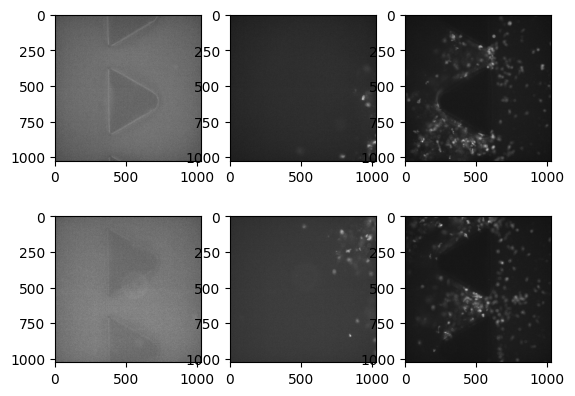

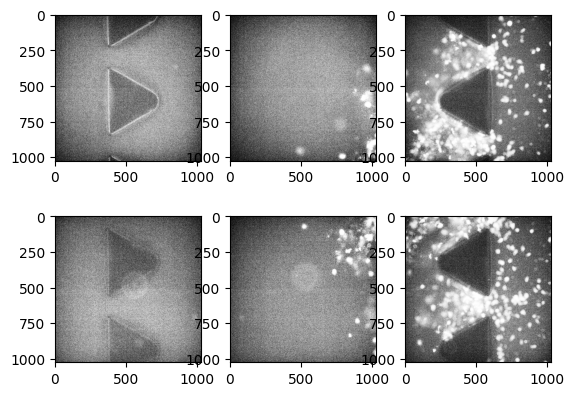

In [3]:
timestamp = imgs[0][0]
positions = info['mosaic_position']
grid = {}
eq_grid = {}
nrow = 0
ncol = 0
z = 8

for pos, tile in zip(positions, timestamp):
    #Recorder of number of rows and cols
    if pos[1]+1>nrow:
        nrow=pos[1]+1
    if pos[0]+1>ncol:
        ncol=pos[0]+1
    #Assigning to the dictionary the corresponding image to each combination of row, col
    eq_tile = exposure.equalize_hist(tile,)
    grid[f'{pos[1]}{pos[0]}']=tile
    eq_grid[f'{pos[1]}{pos[0]}'] = eq_tile

fig, ax = plt.subplots(2,3)
for row in range(0,2):
    for col in range(0,3):
        ax[row, col].imshow(grid[f'{row}{col}'][z], cmap='gray')

fig2, ax2 = plt.subplots(2,3)
for row in range(0,2):
    for col in range(0,3):
        ax2[row, col].imshow(eq_grid[f'{row}{col}'][z], cmap='gray')

In [5]:
translations = [] #Saving vertical an horizontal translations for each image
nccv = -np.inf
ncch = -np.inf
Tvrow = 0
Tvcol = []
Throw = []
Thcol = 0
n=10
for row in range(0, nrow):
    for col in range(0, ncol):
        im = eq_grid[f'{row}{col}'][z]
        H,W = im.shape
        if row!=0:
            im2 = eq_grid[f'{row-1}{col}'][z]
            nccv_, Tvrow_, Tvcol_ = stitching.pciam(im2, im, n)
            print(f'Tv:{nccv_, Tvrow_, Tvcol_}')
            if abs(Tvcol_)<int(W/10):
                Tvcol.append(Tvcol_)
            if nccv<nccv_:
                nccv = nccv_
                Tvrow = Tvrow_
        if col!=0:
            im2 = eq_grid[f'{row}{col-1}'][z]
            ncch_, Throw_, Thcol_ = stitching.pciam(im2, im, n)
            print(f'Th:{ncch_, Throw_, Thcol_}')
            if abs(Throw_)<int(H/10):
                Throw.append(Throw_)
            if ncch<ncch_:
                ncch = ncch_
                Thcol = Thcol_

Tv = [int(Tvrow), int(np.average(Tvcol))]
Th = [int(np.average(Throw)), int(Thcol)]

rr = Th[0]
rc = Tv[1]
drow = Th[1]-rr
dcol = Tv[0]-rc
print(rr, drow, rc, dcol)

Th:(np.float64(0.13767388040202402), np.float64(-19.0), np.float64(-142.0))
Th:(np.float64(0.22606753836317578), np.float64(60.0), np.float64(862.0))
Tv:(np.float64(0.09591157150808975), np.float64(-129.0), np.float64(422.0))
Tv:(np.float64(0.1578128429738107), np.float64(991.0), np.float64(-49.0))
Th:(np.float64(0.10619022080689071), np.float64(1005.0), np.float64(-852.0))
Tv:(np.float64(0.4941164173179308), np.float64(902.0), np.float64(11.0))
Th:(np.float64(0.12896987905500762), np.float64(-915.0), np.float64(356.0))
20 842 -19 921


In [6]:
abs_translations = {}
minr = 0
minc = 0
for row in np.arange(nrow):
    for col in np.arange(ncol):
        abs_translations[f'{row}{col}'] = [int(row*(drow+rr)+col*rr), int(row*rc+col*(dcol+rc))]
        minr_ = abs_translations[f'{row}{col}'][0]
        minc_ = abs_translations[f'{row}{col}'][1]
        if minr_<minr:
            minr=minr_
        if minc_<minc:
            minc=minc_
print(minr, minc)
print(abs_translations)

0 -19
{'00': [0, 0], '01': [20, 902], '02': [40, 1804], '10': [862, -19], '11': [882, 883], '12': [902, 1785]}


(1926, 2847)


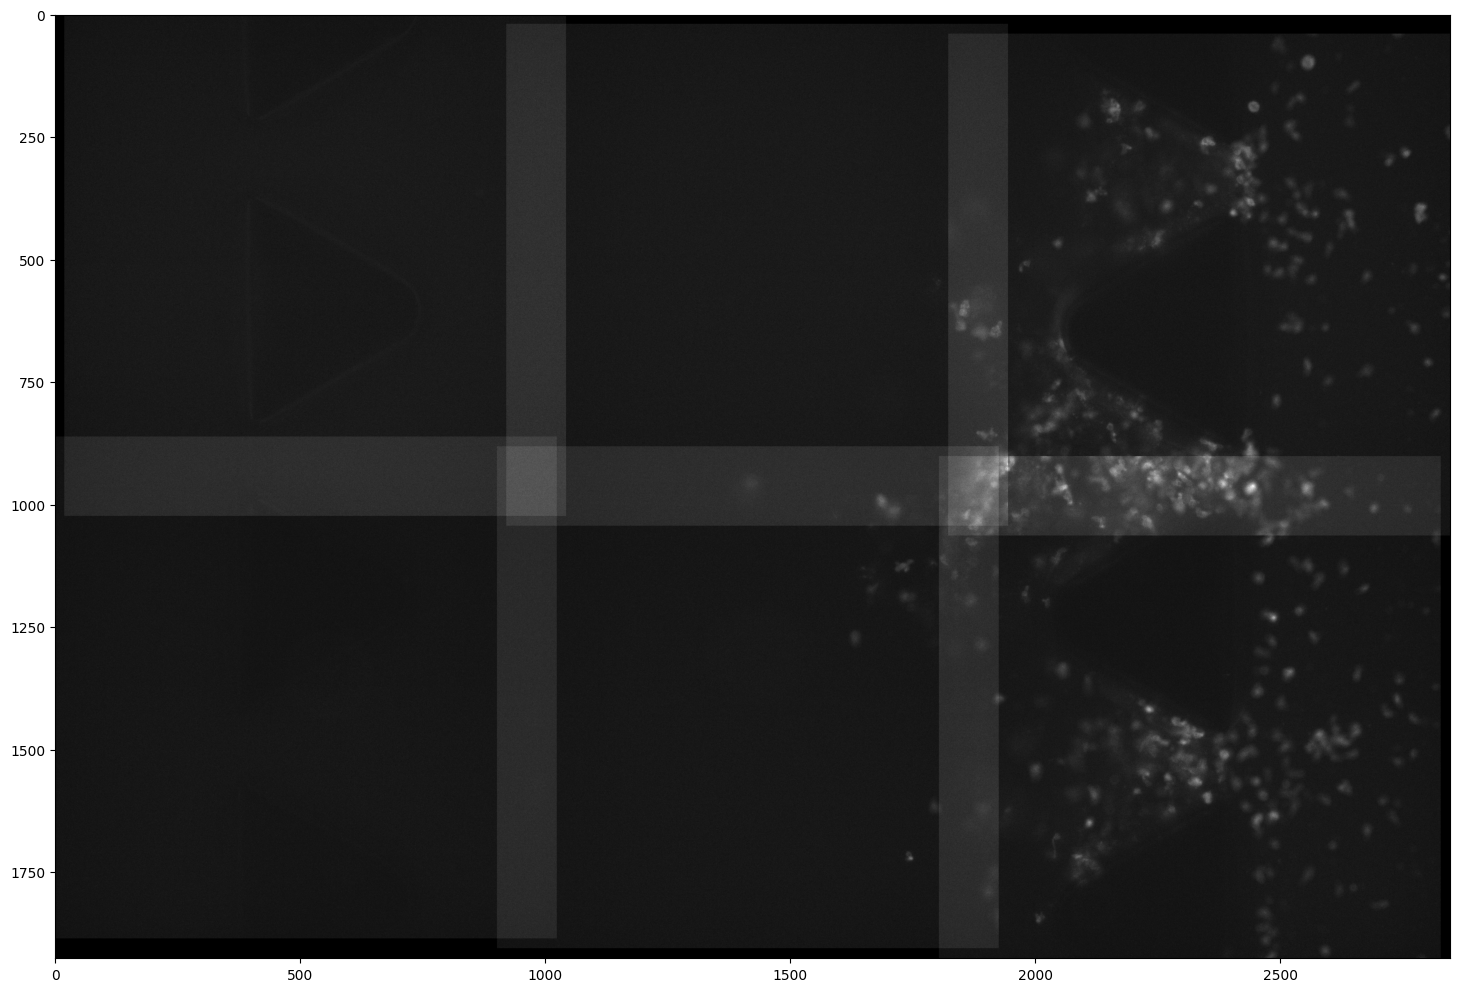

In [7]:
H,W = np.shape(grid['00'][0])
Hmax,Wmax = abs_translations[f'{nrow-1}{ncol-1}']
rerr = abs(minr)
cerr = abs(minc)
result = np.zeros((Hmax+H+2*rerr, Wmax+W+2*cerr))
print(result.shape)
z=7

for trans in abs_translations:
    srow = abs_translations[trans][0] + rerr
    scol = abs_translations[trans][1] + cerr
    erow = srow+H
    ecol = scol+W
    result[srow:erow,scol:ecol] = result[srow:erow,scol:ecol]+grid[trans][z]


plt.figure(figsize=(18,32))
plt.imshow(result, cmap='gray')
plt.show()